# Enhanced policy compression

In the previous notebooks, we've let the model fit the preference weights on its own, and observed that it fits the data better than previous models. This is however not a very constrained model, and it doesn't offer any mechanistic insights regarding how participants determine their preferences.

An alternative to this unconstrained model is to derive the preferences themselves from a model, which would give us insights as to how participants can actually come up with preferences and how they are able learn complex tasks quickly. In this notebook, we will take inspiration from the policy compression framework, which states that optimizing decision under computational constraints requires calculating an optimal policy as:

$$
\pi(a|s) \propto e^{\beta Q(s,a) + log(P(a))}
$$

Where $P(a)$ is the marginal action probability in policy. We have tried to fit that model in the very first notebook and have observed that this did not fit the data so well. Instead, we have realized that participants behaviour follows a mix between decision values derived from an optimal policy and some preferences that reflect the structure of the task. What could be happening is that participants preferences themselves reflect state dependent action probability from the optimal policy. Indeed, our model fitted preferences values associated with each level of each factor of the task, which might be approximations of the marginal action probability in those states, derived from the optimal policy. If this is true, then a model implemening preferences directly derived in that way should outperform our less constrained model, as it should reduce the complexity quite a lot. We will test this idea below

# Preparing the data

In [4]:
import pandas as pd
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import arviz as az
from arviz_stats import bayesian_r2
from scipy.special import logit
import bambi as bmb
from stabst.utils import plt_default
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import warnings
warnings.filterwarnings("ignore")
plt_default()

# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Remove timeout:
data = data[data["timeout"] == 0]
# Flip responses: 1 = accept:
data["response"] = (data["response"] == 0).astype(int)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute categorical regressors that should be somewhat similar to our priors:
# Categorical offer regressor for high and low offer
data['is_12'] = data['is_1'].to_numpy() + data['is_2'].to_numpy()
data['is_34'] = data['is_3'].to_numpy() + data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
data['high_vs_low'] = data['is_34'] - data['is_12']

# Categorical costs regressor
data['is_lc'] = (data['energy_cost'] == 1).astype(int).to_numpy()
data['is_hc'] = (data['energy_cost'] == 2).astype(int).to_numpy()
# Continuous costs regressor
data['hc_vs_lc'] = data['is_hc'] - data['is_lc']

# Categorical transition regressor
data['is_trans1'] = (data['transition'] == 0).to_numpy()
data['is_trans2'] = (data['transition'] == 1).to_numpy()
data['is_trans3'] = (data['transition'] == 2).to_numpy()
data['is_trans4'] = (data['transition'] == 3).to_numpy()
# Continuous transition regressor
data['transition_centered'] = data['transition'] - 2.5

# Categorical energy regressor:
data['e_is_0'] = (data['energy'] == 0).to_numpy()
data['e_is_1'] = (data['energy'] == 1).to_numpy()
data['e_is_2'] = (data['energy'] == 2).to_numpy()
data['e_is_3'] = (data['energy'] == 3).to_numpy()
data['e_is_4'] = (data['energy'] == 4).to_numpy()
data['e_is_5'] = (data['energy'] == 5).to_numpy()
data['e_is_6'] = (data['energy'] == 6).to_numpy()

# Fitting competing models:

We will compare the previous model with an interaction between the decision values and fitted preferences against a model where the preferences are derived directly from the optimal policy:

$$
\eta = \beta_{dv} * DV + \beta_{pref} * preferences
$$

Where:
$$
preference =  logit(P(a=1|o=1)) + logit(P(a=1|o=2)) + ... + logit(P(a=1|e=6))
$$

For this, we need to compute the marginal probability under each level of each factors of our state space:

In [5]:
# Compute the level specific action probability under the optimal policy:
action_prob = {
    "energy": {
        0: [],
        1: [],
        2: [],
        3: [],
        4: [],
        5: [],
        6: []
    },
    "offer": {
        1: [],
        2: [],
        3: [],
        4: []
    },
    "cc": {
        1: [],
        2: []
    },
    "fc": {
        1: [],
        2: []
    }

}

# Loop through each factor:
for fact_i, fact in enumerate(action_prob.keys()):
    # Loop through each level:
    for level in action_prob[fact].keys():
        p_a = []
        # Extract the states decision values:
        for state in task_mdp.states:
            if state[fact_i] == level: 
                dv = Q_full[task_mdp.s2i[state], 1] - Q_full[task_mdp.s2i[state], 0]
                p_a.append(1 / (1 + np.exp(-dv)))
        action_prob[fact][level] = np.mean(p_a)

# Add to the data frame:
offer_pref, cc_pref, fc_pref, energy_pref = [], [], [], []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    offer_pref.append(action_prob["offer"][o])
    cc_pref.append(action_prob["cc"][cc])
    fc_pref.append(action_prob["fc"][fc])
    energy_pref.append(action_prob["energy"][e])
data['offer_pref'] = logit(offer_pref)
data['cc_pref'] = logit(cc_pref)
data['fc_pref'] = logit(fc_pref)
data['energy_pref'] = logit(energy_pref)

In [ ]:
traces = {}
if os.path.exists("../../data/bids/limited_energy/derivatives/models/enhanced_policy_model_trace.nc"):
    idata = az.from_netcdf("../../data/bids/limited_energy/derivatives/models/enhanced_policy_model_trace.nc")
    traces['enhanced_policy_model'] = idata
else:

    # Dependent variable
    y = data['response']
    # Independent variable
    intercept = np.ones(data.shape[0])
    planning_regressor = np.squeeze(data[['dv']].to_numpy())
    pref_regressor = data[['offer_pref', 'cc_pref', 'fc_pref', 'energy_pref']]
    # Random effects
    subj_idx_raw, subj_labels = pd.factorize(data["vpn"])

    # Set coordinates:
    coords = {
        "subject": subj_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_offer", "B_costs", "B_future_costs", "B_energy"],
        "coef_interaction": ["slope"],
    }

    # Model:
    with pm.Model(coords=coords) as planning_preferences_interaction_model:

        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", planning_regressor)
        preferences = pm.Data("preferences", pref_regressor)
        subj_idx = pm.Data("subj_idx", subj_idx_raw.astype("int32"))

        # Hyperpriors:
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                            dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                            dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                            dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                            dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', 
                                    (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the entropy:
        entropy = pm.Deterministic(
            "entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior)
        )
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=1000,
            tune=1000,
            idata_kwargs={"log_likelihood": True},
        )

    # Add the idata to the rest:
    traces['enhanced_policy_model'] = idata
    # Save the trace to file:
    if not os.path.exists("../../data/bids/limited_energy/derivatives/models/"):
        os.makedirs("../../data/bids/limited_energy/derivatives/models/")
    az.to_netcdf(idata, "../../data/bids/limited_energy/derivatives/models/enhanced_policy_model_trace.nc")

array([[<Axes: title={'center': 'beta_intercept'}>,
        <Axes: title={'center': 'beta_intercept'}>],
       [<Axes: title={'center': 'beta_planning'}>,
        <Axes: title={'center': 'beta_planning'}>],
       [<Axes: title={'center': 'beta_pref'}>,
        <Axes: title={'center': 'beta_pref'}>],
       [<Axes: title={'center': 'beta_interaction'}>,
        <Axes: title={'center': 'beta_interaction'}>]], dtype=object)

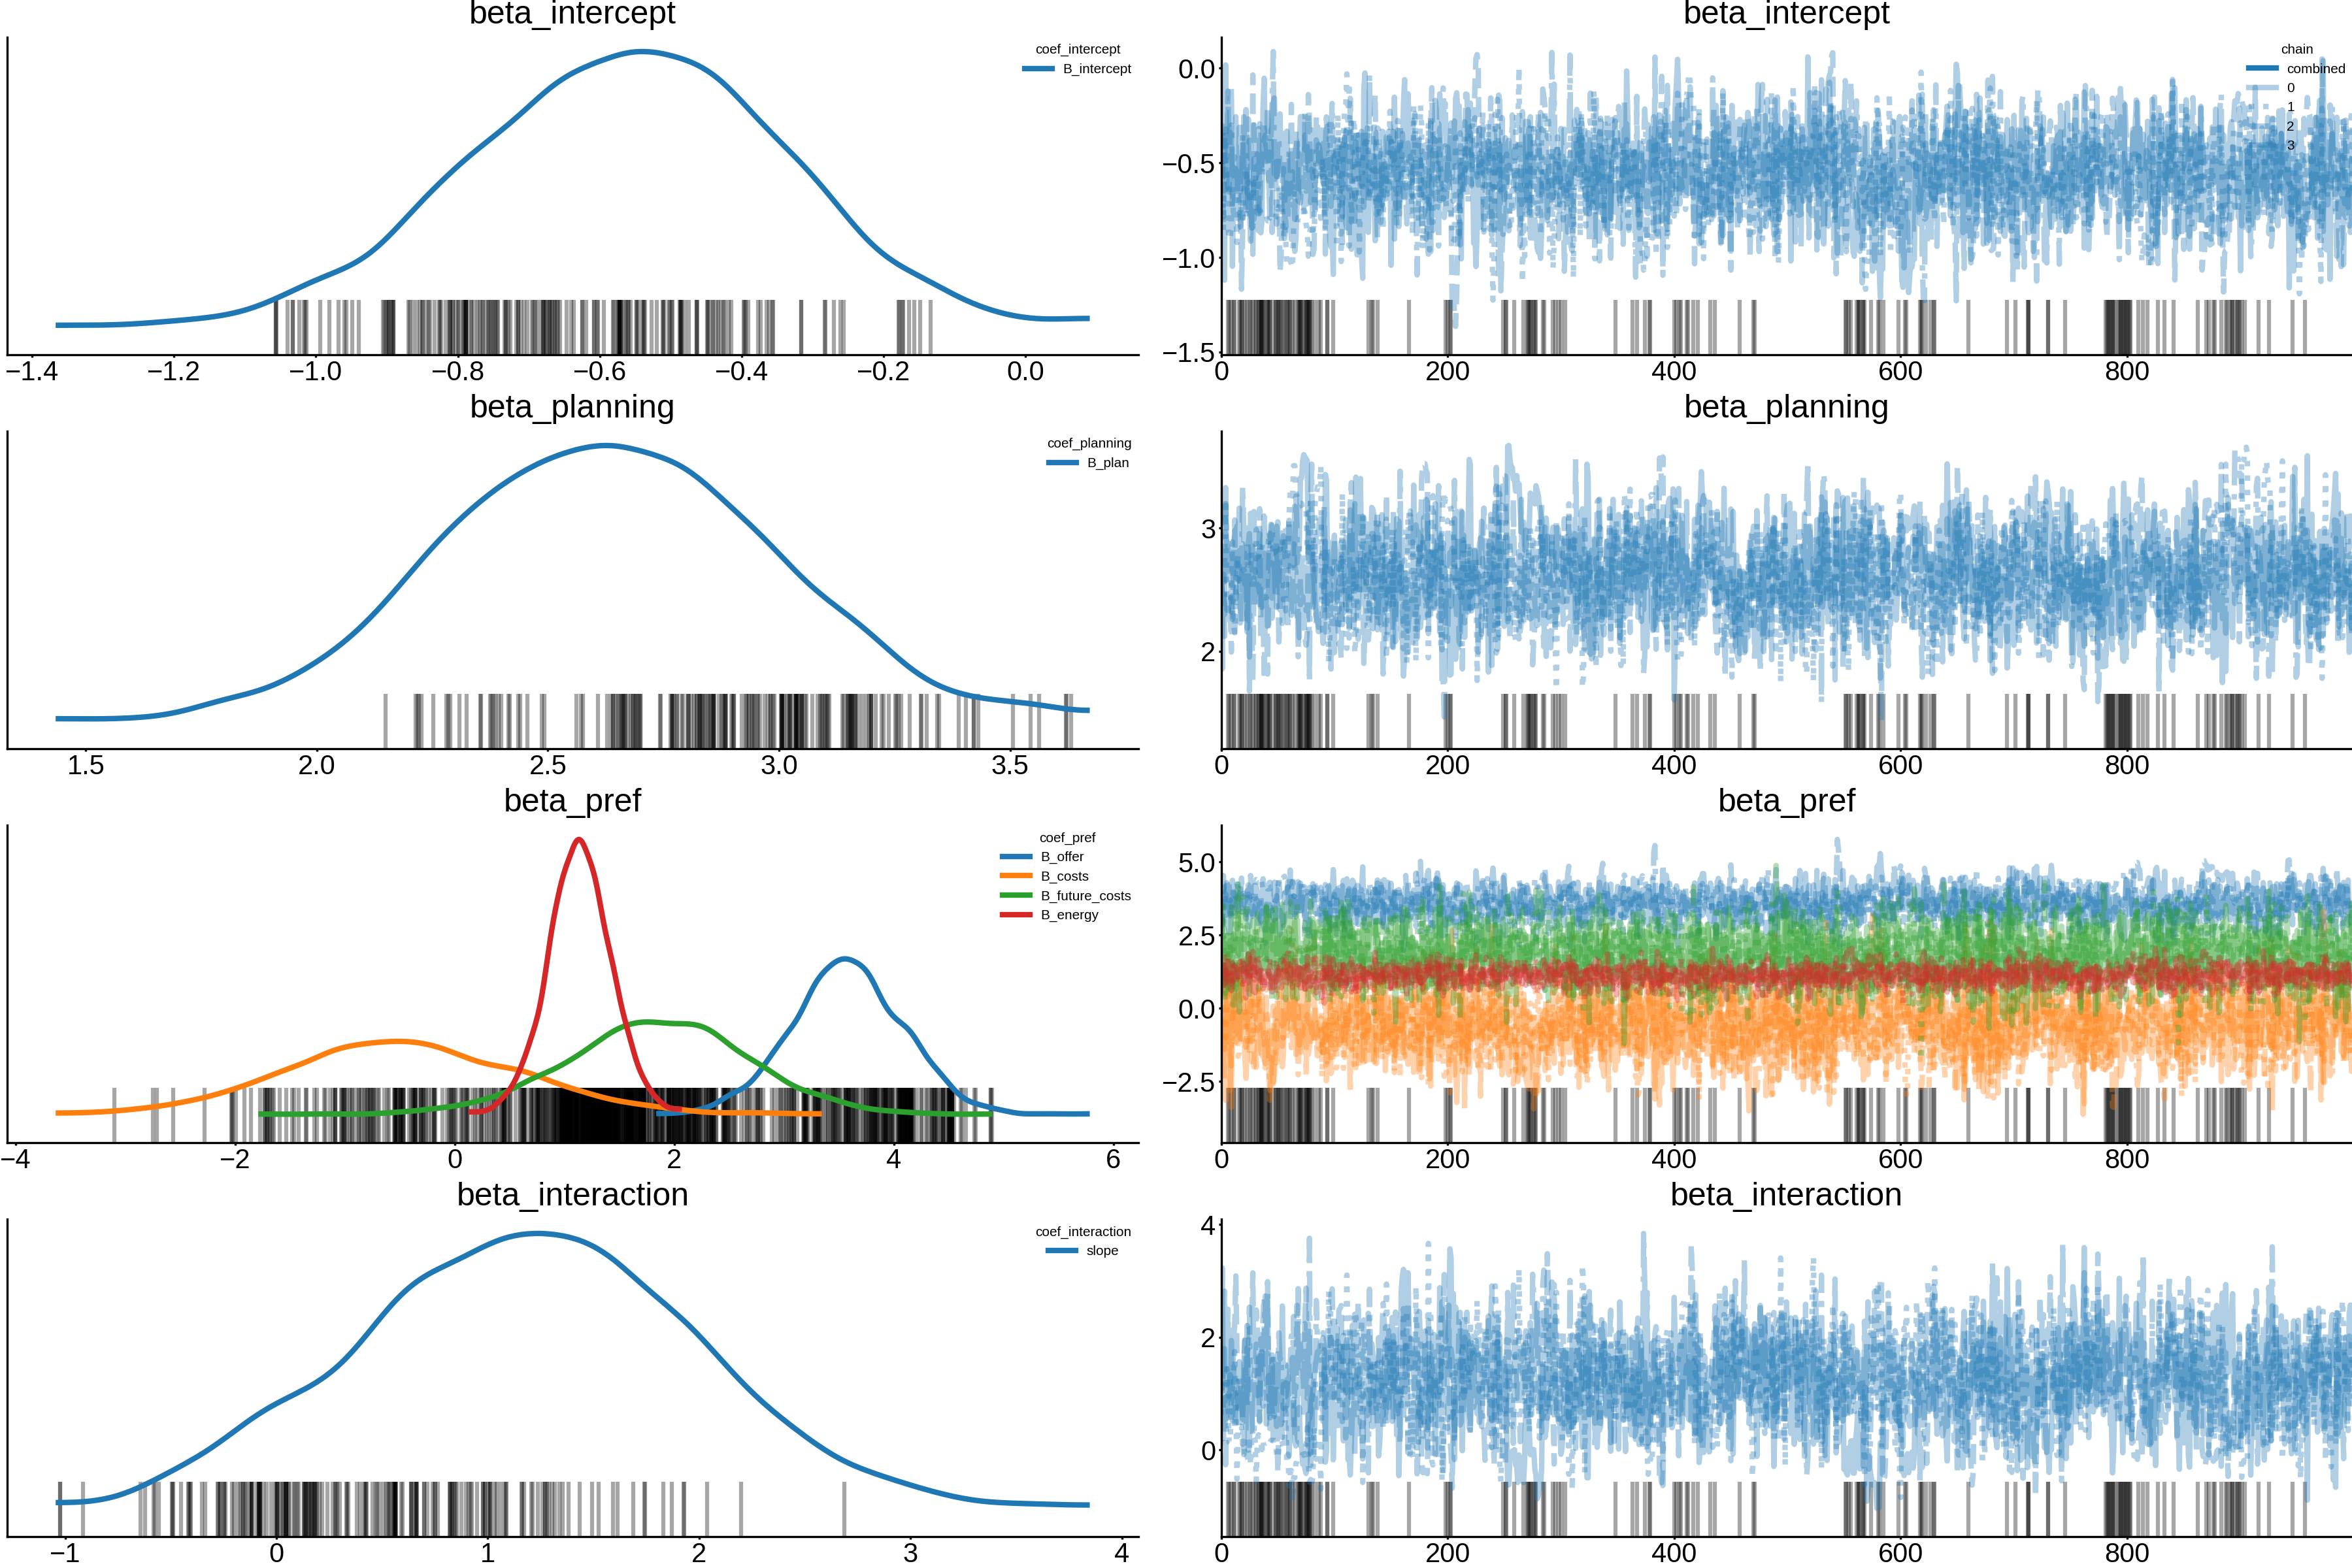

In [12]:
az.plot_trace(traces['enhanced_policy_model'], var_names=["beta_intercept", "beta_planning", "beta_pref", "beta_interaction"], legend=True, combined=True)

In [7]:
if os.path.exists("../../data/bids/limited_energy/derivatives/models/planning_preferences_interaction_model_trace.nc"):
    idata = az.from_netcdf("../../data/bids/limited_energy/derivatives/models/planning_preferences_interaction_model_trace.nc")
    traces['planning_preferences_interaction_model'] = idata
else:

    # Dependent variable
    y = data['response']
    # Independent variable
    intercept = np.ones(data.shape[0])
    planning_regressor = np.squeeze(data[['dv']].to_numpy())
    pref_regressor = data[['is_1', 'is_2', 'is_3', 'is_4', 
                            'is_lc', 'is_hc', 
                            'is_trans1', 'is_trans2', 'is_trans3', 'is_trans4', 
                            'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6']]
    # Random effects
    subj_idx_raw, subj_labels = pd.factorize(data["vpn"])

    # Set coordinates:
    coords = {
        "subject": subj_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_is_1", "B_is_2", "B_is_3", "B_is_4", 
                        "B_islc", "B_ishc", 
                        "B_istrans1", "B_istrans2", "B_istrans3", "B_istrans4", 
                        "B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", "B_e_is_4", "B_e_is_5", "B_e_is_6"],
        "coef_interaction": ["slope"],
    }

    # Model:
    with pm.Model(coords=coords) as planning_preferences_interaction_model:

        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", planning_regressor)
        preferences = pm.Data("preferences", pref_regressor)
        subj_idx = pm.Data("subj_idx", subj_idx_raw.astype("int32"))

        # Hyperpriors:
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                            dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                            dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                            dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                            dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', 
                                    (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the entropy:
        entropy = pm.Deterministic(
            "entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior)
        )
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=1000,
            tune=1000,
            idata_kwargs={"log_likelihood": True},
        )

    # Add the idata to the rest:
    traces['planning_preferences_interaction_model'] = idata
    # Save the trace to file:
    if not os.path.exists("../../data/bids/limited/energy/derivatives/models/"):
        os.makedirs("../../data/bids/limited/energy/derivatives/models/")
    az.to_netcdf(idata, "../../data/bids/limited/energy/derivatives/models/planning_preferences_interaction_model_trace.nc")

We can investigate the fit of the model by first looking at the sampling traces for each key parameters. 

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
planning_preferences_interaction_model,0,-1507.472881,269.627916,0.000000,0.931586,48.995286,0.000000,True,log
enhanced_policy_model,1,-1698.919346,182.394202,191.446466,0.068414,51.634450,23.136903,True,log


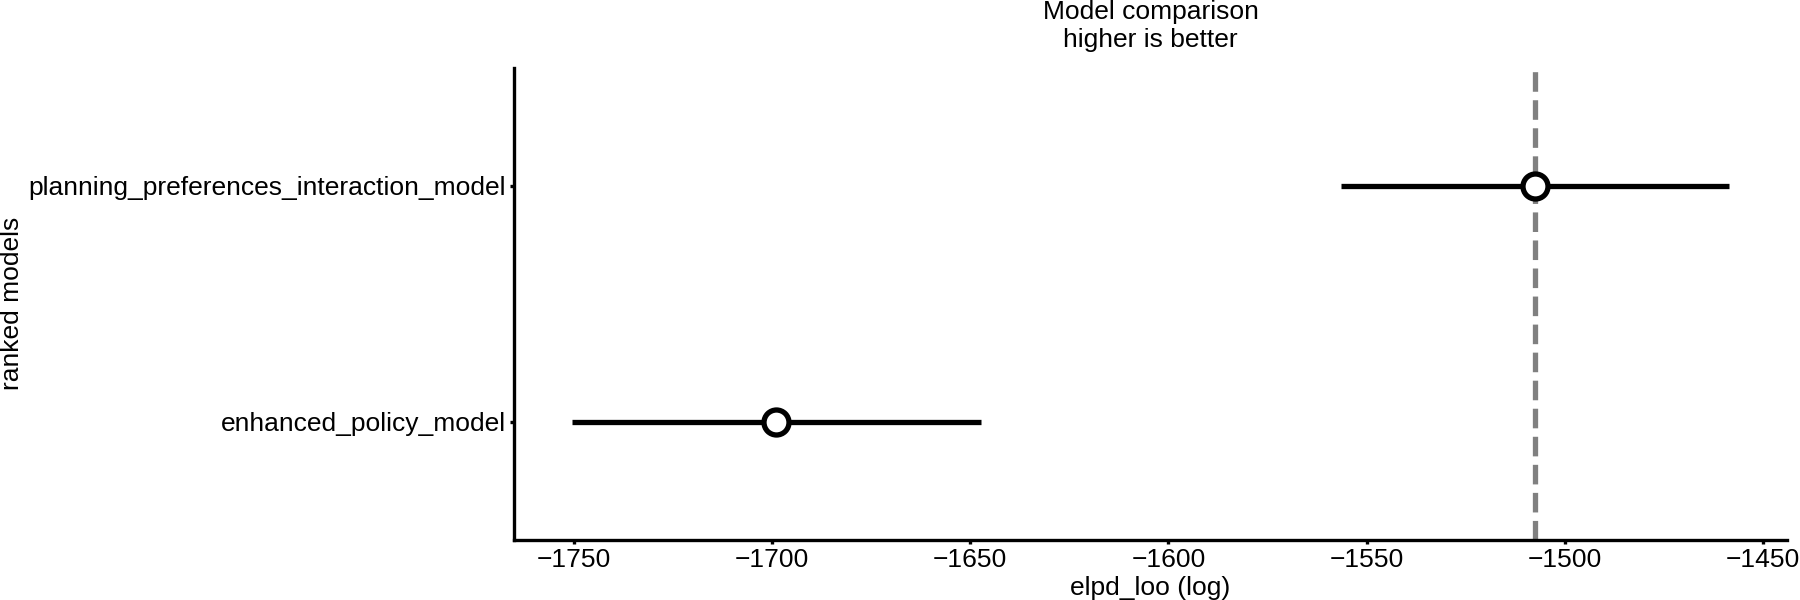

In [8]:
# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

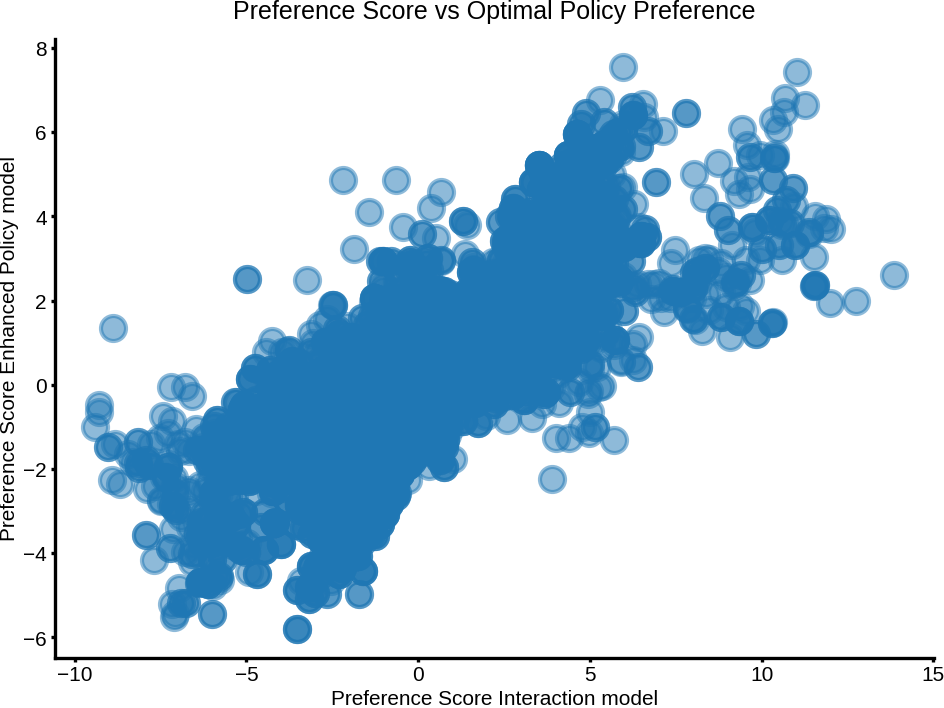

In [13]:
data['preference_score1'] = np.mean(traces['planning_preferences_interaction_model'].posterior["preference"], axis=(0, 1))
data['preference_score2'] = np.mean(traces['enhanced_policy_model'].posterior["preference"], axis=(0, 1))

fig, ax = plt.subplots()
ax.scatter(data['preference_score1'], data['preference_score2'], alpha=0.5)
ax.set_xlabel('Preference Score Interaction model')
ax.set_ylabel('Preference Score Enhanced Policy model')
ax.set_title('Preference Score vs Optimal Policy Preference')
plt.show()